# 01. EDA — 올리브영 데이터 탐색

**목적**: 1주차에 수집한 raw 데이터(products / rankings / reviews)의 품질과 분포를 확인하고,  
이후 피처 엔지니어링에서 다룰 핵심 변수를 선정한다.

**DB**: `data/raw/oliveyoung.db` (SQLite) — DuckDB로 ATTACH해서 분석 SQL 작성  
**수집일**: 2026-04-27 ~ 2026-04-28  
**대상**: 스킨케어·색조 메이크업 Top 100 × 2카테고리 = 200개 상품, 리뷰 18,695건

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
fm.fontManager.addfont("/System/Library/Fonts/AppleSDGothicNeo.ttc")
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 30)

# Jupyter CWD는 실행 위치에 따라 프로젝트 루트 or notebooks/ 중 하나
# 존재 여부로 감지해 절대 경로 확정 (상대 경로는 DuckDB CWD 불일치로 disk I/O error 발생)
_cwd = Path.cwd()
if (_cwd / "data/raw/oliveyoung.db").exists():
    DB_PATH = str(_cwd / "data/raw/oliveyoung.db")        # CWD = 프로젝트 루트
elif (_cwd.parent / "data/raw/oliveyoung.db").exists():
    DB_PATH = str(_cwd.parent / "data/raw/oliveyoung.db") # CWD = notebooks/
else:
    raise FileNotFoundError(f"oliveyoung.db를 찾을 수 없음. CWD: {_cwd}")

con = duckdb.connect()
con.execute(f"ATTACH '{DB_PATH}' AS oy (TYPE sqlite)")
print("DB 연결 완료:", DB_PATH)

DB 연결 완료: /Users/gimgyumin/Desktop/Developer/데이터 분석/oliveyoung-hit-prediction/data/raw/oliveyoung.db


---
## 1. 기본 현황 파악

In [2]:
# 테이블별 행 수
tables = ["products", "rankings", "reviews"]
for t in tables:
    n = con.execute(f"SELECT COUNT(*) FROM oy.{t}").fetchone()[0]
    print(f"{t:12s}: {n:,} rows")

products    : 200 rows
rankings    : 200 rows
reviews     : 18,695 rows


In [3]:
# 컬럼 목록 및 NULL 비율
def null_report(table: str) -> pd.DataFrame:
    df = con.execute(f"SELECT * FROM oy.{table}").df()
    total = len(df)
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "null_count": df.isnull().sum(),
        "null_pct": (df.isnull().sum() / total * 100).round(1),
        "sample": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    return report

print("=== products ===")
display(null_report("products"))

=== products ===


,dtype,null_count,null_pct,sample
product_id,str,0,0.0,A000000012239
name,str,0,0.0,[24시간커버지속/올리브영 6년연속 1등] 루나 롱래스팅 팁 컨실러 EX 20colors
brand,str,0,0.0,루나
category_main,str,0,0.0,메이크업
category_sub,str,0,0.0,베이스메이크업
price,int64,0,0.0,12700
price_original,Int64,17,8.5,17000
launch_date_est,datetime64[us],0,0.0,2026-02-25 00:00:00
review_count_total,int64,0,0.0,46017
rating_avg,float64,0,0.0,4.7


In [4]:
print("=== rankings ===")
display(null_report("rankings"))


=== rankings ===


,dtype,null_count,null_pct,sample
snapshot_id,int64,0,0.0,1
product_id,str,0,0.0,A000000222833
category,str,0,0.0,스킨케어
rank,int64,0,0.0,1
snapshot_date,datetime64[us],0,0.0,2026-04-27 00:00:00


In [5]:
print("\n=== reviews ===")
display(null_report("reviews"))


=== reviews ===


,dtype,null_count,null_pct,sample
review_id,str,0,0.0,56489214
product_id,str,0,0.0,A000000012239
rating,int64,0,0.0,1
content,str,0,0.0,아쌰갈이게뭐애요 걍 다 뜨고 끼이고 내 화장은 완벽한데 뭐가 문제지? 싶었더니 니가...
written_at,datetime64[us],0,0.0,2026-03-04 00:00:00
helpful_count,int64,0,0.0,38
has_photo,int64,0,0.0,0
author_id_masked,str,0,0.0,fcda9684c073ebdf
author_skin_type,str,6349,34.0,A02
crawled_at,datetime64[us],0,0.0,2026-04-26 19:12:51


### 1.3 중복·범위 점검

PK 중복과 숫자 컬럼 범위 위반을 한 번에 잡아둔다 — EDA 후반에서 "이게 왜 이렇지"로 시간 버리는 걸 사전 차단.

In [6]:
# PK / 논리 중복 체크
checks = [
    ("products.product_id",
     con.execute("SELECT COUNT(*) - COUNT(DISTINCT product_id) FROM oy.products").fetchone()[0]),
    ("reviews.review_id",
     con.execute("SELECT COUNT(*) - COUNT(DISTINCT review_id) FROM oy.reviews").fetchone()[0]),
    ("rankings.snapshot_id",
     con.execute("SELECT COUNT(*) - COUNT(DISTINCT snapshot_id) FROM oy.rankings").fetchone()[0]),
    ("rankings (snapshot_date, category, rank) 논리",
     con.execute("""
        SELECT COUNT(*) FROM (
            SELECT snapshot_date, category, rank, COUNT(*) c
            FROM oy.rankings GROUP BY 1, 2, 3 HAVING c > 1
        )
     """).fetchone()[0]),
]
for label, dup in checks:
    mark = "✅" if dup == 0 else "⚠️"
    print(f"{mark} {label}: 중복 {dup}건")

✅ products.product_id: 중복 0건
✅ reviews.review_id: 중복 0건
✅ rankings.snapshot_id: 중복 0건
✅ rankings (snapshot_date, category, rank) 논리: 중복 0건


In [7]:
# 숫자 컬럼 범위 위반 체크
range_checks = [
    ("products.price <= 0",
     "SELECT COUNT(*) FROM oy.products WHERE price IS NOT NULL AND price <= 0"),
    ("products.price > 1,000,000",
     "SELECT COUNT(*) FROM oy.products WHERE price > 1000000"),
    ("products.rating_avg 0~5 밖",
     "SELECT COUNT(*) FROM oy.products WHERE rating_avg IS NOT NULL AND (rating_avg < 0 OR rating_avg > 5)"),
    ("reviews.rating 0~5 밖",
     "SELECT COUNT(*) FROM oy.reviews WHERE rating IS NOT NULL AND (rating < 0 OR rating > 5)"),
    ("reviews.helpful_count < 0",
     "SELECT COUNT(*) FROM oy.reviews WHERE helpful_count < 0"),
    ("rankings.rank 1~100 밖",
     "SELECT COUNT(*) FROM oy.rankings WHERE rank < 1 OR rank > 100"),
]
for label, sql in range_checks:
    n = con.execute(sql).fetchone()[0]
    mark = "✅" if n == 0 else "⚠️"
    print(f"{mark} {label}: {n}건")

✅ products.price <= 0: 0건
✅ products.price > 1,000,000: 0건
✅ products.rating_avg 0~5 밖: 0건
✅ reviews.rating 0~5 밖: 0건
✅ reviews.helpful_count < 0: 0건
✅ rankings.rank 1~100 밖: 0건


---
## 2. products 탐색

In [8]:
products = con.execute("SELECT * FROM oy.products").df()
products.head(3)

,product_id,name,brand,category_main,category_sub,price,price_original,launch_date_est,review_count_total,rating_avg,url,crawled_at
0,A000000012239,[24시간커버지속/올리브영 6년연속 1등] 루나 롱래스팅 팁 컨실러 EX 20colors,루나,메이크업,베이스메이크업,12700,17000,2026-02-25,46017,4.7,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
1,A000000109650,[수채화블러셔] 3CE 무드레시피 페이스 블러쉬 단품/기획,3CE,메이크업,베이스메이크업,16000,20000,2026-02-26,29235,4.8,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
2,A000000117541,[베스트 올인원]우르오스 올인원 200ml 2종 택 1(증정기획/단품),우르오스,스킨케어,로션,22900,29700,2022-07-21,7090,4.8,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45


In [9]:
# 카테고리 분포
cat_dist = (
    products.groupby(["category_main", "category_sub"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(cat_dist)

,category_main,category_sub,count
1,메이크업,베이스메이크업,48
8,스킨케어,에센스/세럼/앰플,43
9,스킨케어,크림,36
0,메이크업,립메이크업,27
2,메이크업,아이메이크업,25
3,스킨케어,로션,6
5,스킨케어,스킨/토너,6
4,스킨케어,미스트/오일,5
6,스킨케어,스킨케어 디바이스,3
7,스킨케어,스킨케어세트,1


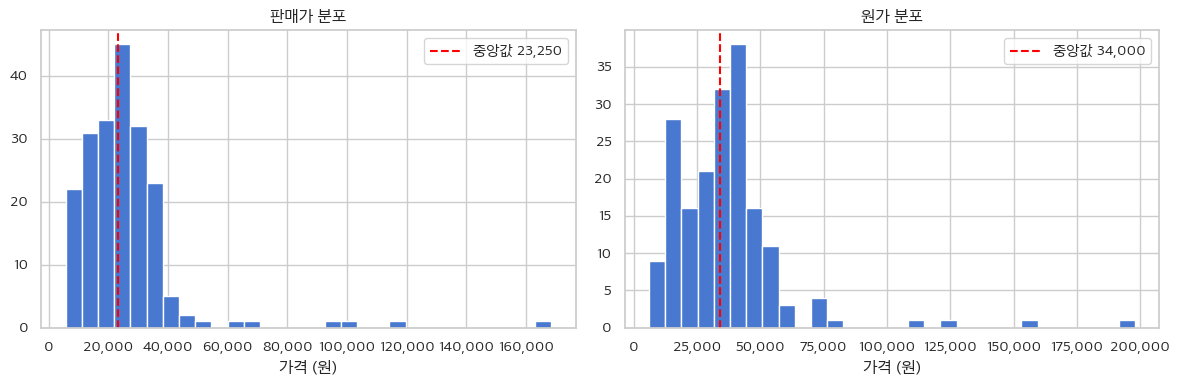

In [10]:
# 가격 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ["price", "price_original"], ["판매가", "원가"]):
    data = products[col].dropna()
    ax.hist(data, bins=30, edgecolor="white")
    ax.set_title(f"{label} 분포")
    ax.set_xlabel("가격 (원)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.axvline(data.median(), color="red", linestyle="--", label=f"중앙값 {data.median():,.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/price_dist.png", dpi=150)
plt.show()

count    200.000
mean       4.777
std        0.085
min        4.300
25%        4.700
50%        4.800
75%        4.800
max        5.000
Name: rating_avg, dtype: float64


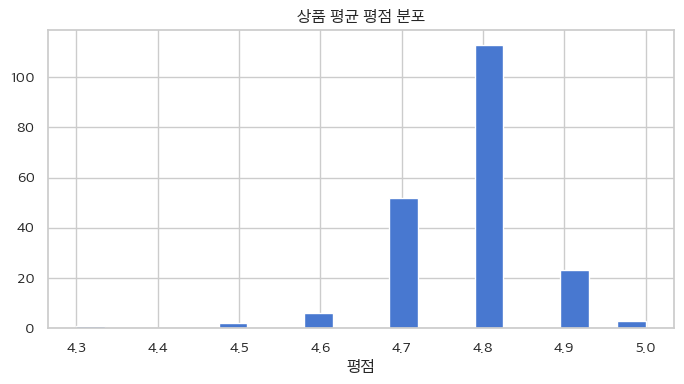

In [11]:
# 평점 분포
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(products["rating_avg"].dropna(), bins=20, edgecolor="white")
ax.set_title("상품 평균 평점 분포")
ax.set_xlabel("평점")
print(products["rating_avg"].describe().round(3))
plt.tight_layout()
plt.show()

count       200.0
mean      19873.5
std       29444.9
min          37.0
25%        3119.2
50%        9441.0
75%       27358.8
max      253061.0
Name: review_count_total, dtype: float64


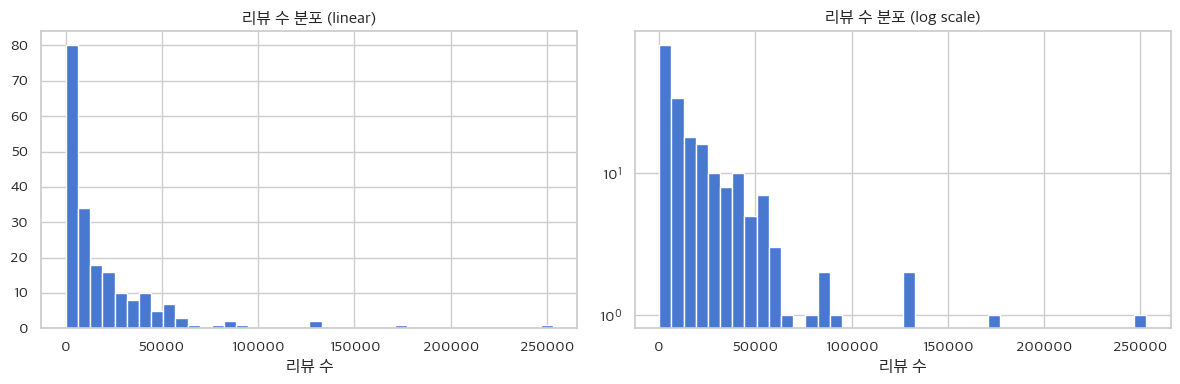

In [12]:
# 리뷰 수 분포 (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rv = products["review_count_total"].dropna()

axes[0].hist(rv, bins=40, edgecolor="white")
axes[0].set_title("리뷰 수 분포 (linear)")

axes[1].hist(rv, bins=40, edgecolor="white", log=True)
axes[1].set_title("리뷰 수 분포 (log scale)")

for ax in axes:
    ax.set_xlabel("리뷰 수")

print(rv.describe().round(1))
plt.tight_layout()
plt.show()

In [13]:
# 출시일 추정 분포 (연도별)
products["launch_year"] = pd.to_datetime(products["launch_date_est"]).dt.year
launch_by_year = products["launch_year"].value_counts().sort_index()
print(launch_by_year.to_string())

launch_year
2022      7
2023      5
2024      8
2025     16
2026    164


### 2.5 launch_date_est 신뢰도 검증

출시일을 "최초 리뷰 작성일"로 추정했으므로, 추정값이 합리적인지·리뷰가 적어 추정 오차가 클 만한 케이스 비율을 점검한다.

In [14]:
# 1) NULL/이상치 카운트
today = pd.Timestamp("2026-04-28")
launch = pd.to_datetime(products["launch_date_est"])

null_count = launch.isna().sum()
future = (launch > today).sum()
old = (launch < pd.Timestamp("2020-01-01")).sum()

print(f"NULL: {null_count}건")
print(f"미래 날짜(>{today.date()}): {future}건")
print(f"2020-01-01 이전: {old}건")

NULL: 0건
미래 날짜(>2026-04-28): 0건
2020-01-01 이전: 0건


In [15]:
# 2) 리뷰 수가 적은 상품 = 추정 오차 위험군
low_10 = (products["review_count_total"] < 10).sum()
low_50 = (products["review_count_total"] < 50).sum()
print(f"리뷰 < 10건 상품: {low_10}개 ({low_10/len(products):.1%})")
print(f"리뷰 < 50건 상품: {low_50}개 ({low_50/len(products):.1%})")

# 샘플 5개 — 리뷰 적은 상품의 launch_date_est가 합리적으로 보이는지 수기 확인
print("\n--- 리뷰 수 적은 상품 샘플 5개 (수기 검증용) ---")
display(
    products[["product_id", "name", "brand", "category_main",
              "launch_date_est", "review_count_total", "rating_avg"]]
    .sort_values("review_count_total")
    .head(5)
)

리뷰 < 10건 상품: 0개 (0.0%)
리뷰 < 50건 상품: 1개 (0.5%)

--- 리뷰 수 적은 상품 샘플 5개 (수기 검증용) ---


,product_id,name,brand,category_main,launch_date_est,review_count_total,rating_avg
199,A000000252785,[NEW] 컬러그램 누디 블러 스틱 11 COLOR,컬러그램,메이크업,2026-04-22,37,4.8
195,A000000251651,[3세대 리뉴얼/단독 증정] 닥터지 레드 블레미쉬 클리어 수딩 크림 EX 70ml,닥터지,스킨케어,2026-04-08,77,4.8
194,A000000251569,[NEW리뷰인증이벤트][OY단독컬러/재유PICK] 3CE 구미 오일 틴트 4g,3CE,메이크업,2026-04-20,88,4.9
152,A000000245794,[단독기획]폴라초이스 바하 리퀴드 엑스폴리언트 118ml 기획 (+바하 리퀴드 30ml),폴라초이스,스킨케어,2026-01-01,133,4.8
160,A000000248500,[NEW/리뉴얼] 아누아 어성초 77 B3 징크 트러블 세럼 30ml 더블 기획,아누아,스킨케어,2026-03-03,141,4.7


In [16]:
# 3) launch_date_est가 첫 리뷰일과 일치하는지 (정의상 일치해야 함)
# reviews DataFrame은 Section 4에서 로드하므로 여기선 DuckDB 직접 쿼리
first_review = con.execute("""
    SELECT product_id, MIN(written_at) AS first_review_at
    FROM oy.reviews
    GROUP BY product_id
""").df()
first_review["first_review_at"] = pd.to_datetime(first_review["first_review_at"])

merged = products.merge(first_review, on="product_id", how="left")
merged["launch_date_est"] = pd.to_datetime(merged["launch_date_est"])
merged["diff_days"] = (merged["first_review_at"] - merged["launch_date_est"]).dt.days.abs()

mismatch = (merged["diff_days"] > 0).sum()
print(f"launch_date_est ≠ first_review 인 상품: {mismatch}개")
print("  (정의상 0이어야 정상 — 0이 아니면 크롤러 로직 점검 필요)")

launch_date_est ≠ first_review 인 상품: 1개
  (정의상 0이어야 정상 — 0이 아니면 크롤러 로직 점검 필요)


In [17]:
# 핵심 컬럼만
cols = [c for c in ["product_id", "product_name", "name", "category", "launch_date_est", "first_review_at", "diff_days", "review_count_total"] if c in merged.columns]
display(merged.loc[merged["diff_days"] > 0, cols])

,product_id,name,launch_date_est,first_review_at,diff_days,review_count_total
173,A000000250214,[슈링크홈디바이스] 바이오힐보 프로바이오덤 콜라겐 세럼 30ml 기획,2026-03-01,2026-04-01,31,1437


---
## 3. rankings 탐색

In [18]:
rankings = con.execute("SELECT * FROM oy.rankings").df()
print("스냅샷 날짜:", rankings["snapshot_date"].unique())
print("카테고리:", rankings["category"].unique())
rankings.head(3)

스냅샷 날짜: <DatetimeArray>
['2026-04-27 00:00:00']
Length: 1, dtype: datetime64[us]
카테고리: <StringArray>
['스킨케어', '색조메이크업']
Length: 2, dtype: str


,snapshot_id,product_id,category,rank,snapshot_date
0,1,A000000222833,스킨케어,1,2026-04-27
1,2,A000000222698,스킨케어,2,2026-04-27
2,3,A000000250098,스킨케어,3,2026-04-27


---
## 4. reviews 탐색

In [22]:
reviews = con.execute("SELECT * FROM oy.reviews").df()
reviews["written_at"] = pd.to_datetime(reviews["written_at"])
print(f"리뷰 날짜 범위: {reviews['written_at'].min().date()} ~ {reviews['written_at'].max().date()}")
reviews.head(3)

리뷰 날짜 범위: 2022-03-25 ~ 2026-04-28


,review_id,product_id,rating,content,written_at,helpful_count,has_photo,author_id_masked,author_skin_type,crawled_at
0,56489214,A000000012239,1,아쌰갈이게뭐애요 걍 다 뜨고 끼이고 내 화장은 완벽한데 뭐가 문제지? 싶었더니 니가...,2026-03-04,38,0,fcda9684c073ebdf,A02,2026-04-26 19:12:51
1,58480618,A000000012239,5,"커버력이 확실한 컨실러로, 잡티나 다크서클 가리기에 매우 만족스러웠습니다.",2026-04-17,4,0,a939720b9e434d7d,A04,2026-04-26 19:12:51
2,56572518,A000000012239,5,"컨실러 중 클리오 란제리, 루나 15N, 웨이크메이크 10 페어 비교\r\n\r\n...",2026-03-06,25,1,1a18f30abd4da5d4,A06,2026-04-26 19:12:51


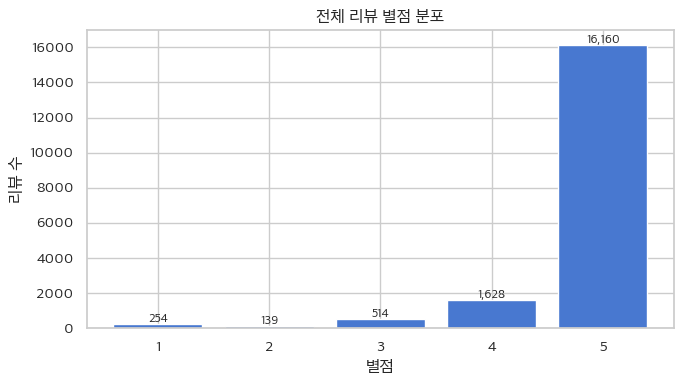

rating
1     1.4
2     0.7
3     2.7
4     8.7
5    86.4


In [23]:
# 별점 분포
fig, ax = plt.subplots(figsize=(7, 4))
rating_counts = reviews["rating"].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, edgecolor="white")
ax.set_title("전체 리뷰 별점 분포")
ax.set_xlabel("별점")
ax.set_ylabel("리뷰 수")
for x, y in zip(rating_counts.index, rating_counts.values):
    ax.text(x, y + 50, f"{y:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
print(reviews["rating"].value_counts(normalize=True).sort_index().mul(100).round(1).to_string())

count    200.0
mean      93.5
std       17.2
min       14.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


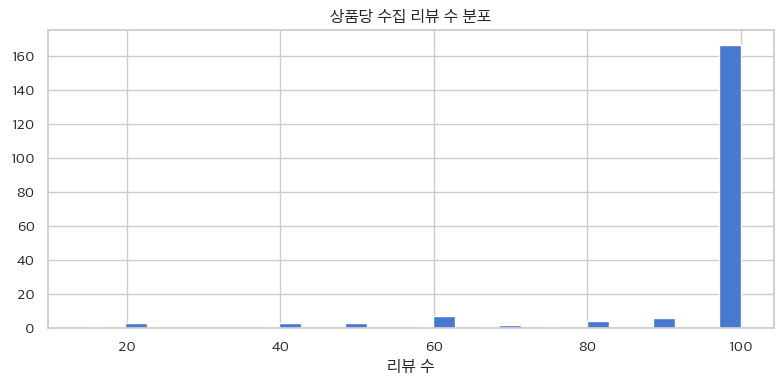

In [24]:
# 상품별 리뷰 수 분포
rv_per_product = reviews.groupby("product_id").size()
print(rv_per_product.describe().round(1))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rv_per_product, bins=30, edgecolor="white")
ax.set_title("상품당 수집 리뷰 수 분포")
ax.set_xlabel("리뷰 수")
plt.tight_layout()
plt.show()

포토 리뷰 비율 — 전체 평균: 72.7%


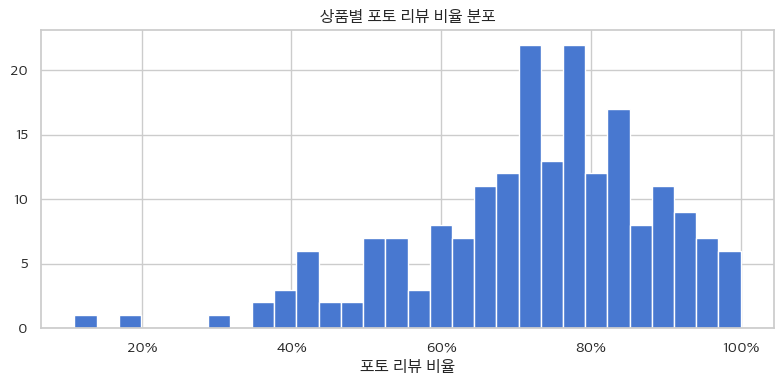

In [25]:
# 포토 리뷰 비율
photo_ratio = reviews.groupby("product_id")["has_photo"].mean()
print(f"포토 리뷰 비율 — 전체 평균: {reviews['has_photo'].mean():.1%}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(photo_ratio, bins=30, edgecolor="white")
ax.set_title("상품별 포토 리뷰 비율 분포")
ax.set_xlabel("포토 리뷰 비율")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

count    18695.0
mean       144.4
std        153.7
min         24.0
25%         46.0
50%         90.0
75%        180.0
max       1389.0
Name: content_len, dtype: float64


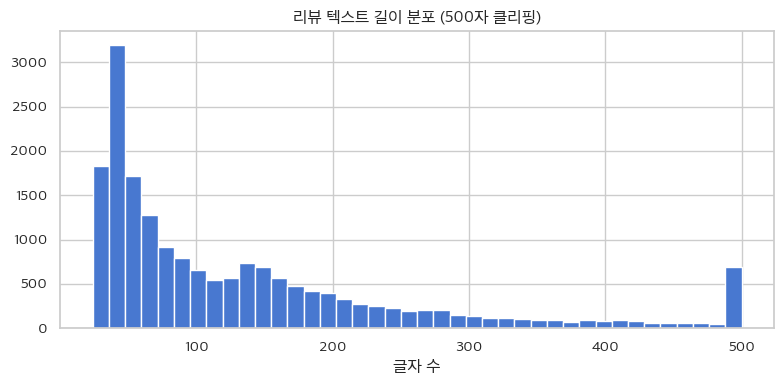

In [26]:
# 리뷰 텍스트 길이
reviews["content_len"] = reviews["content"].fillna("").str.len()
print(reviews["content_len"].describe().round(1))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reviews["content_len"].clip(upper=500), bins=40, edgecolor="white")
ax.set_title("리뷰 텍스트 길이 분포 (500자 클리핑)")
ax.set_xlabel("글자 수")
plt.tight_layout()
plt.show()

In [27]:
# 피부 타입 분포
skin_dist = reviews["author_skin_type"].value_counts(dropna=False)
print(skin_dist.to_string())
print(f"\n피부타입 있는 리뷰 비율: {reviews['author_skin_type'].notna().mean():.1%}")

author_skin_type
NaN    6349
A03    4911
A02    2985
A01    2115
A04    1261
A06     633
A07     270
A05     171

피부타입 있는 리뷰 비율: 66.0%


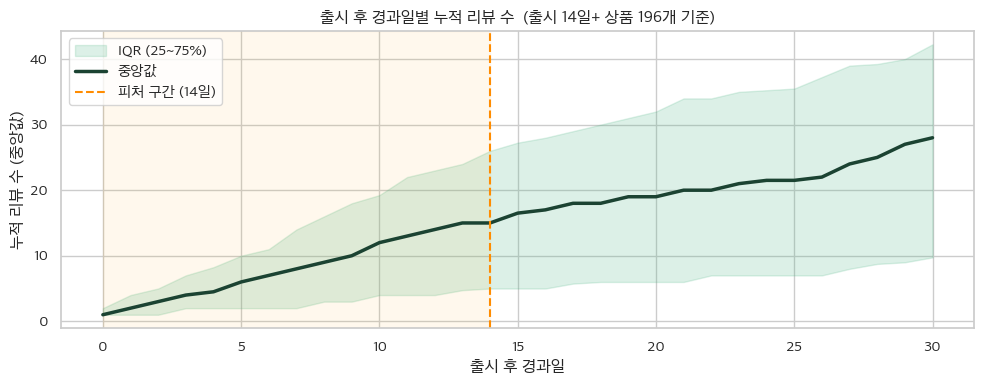

분석 대상: 196개 상품 (출시 14일 이상 경과)
14일 누적 리뷰 — 중앙값: 15건 / Q75: 26건


In [33]:
# 출시 후 경과일별 누적 리뷰 속도
CRAWL_DATE = pd.Timestamp("2026-04-28")
WINDOW = 30        # 표시 범위 (일)
FEATURE_DAYS = 14  # 피처 엔지니어링 구간

rv_early = reviews.merge(
    products[["product_id", "launch_date_est"]],
    on="product_id", how="left"
)
rv_early["days_since_launch"] = (
    rv_early["written_at"] - pd.to_datetime(rv_early["launch_date_est"])
).dt.days

# 14일 이상 경과한 상품만 (피처 구간 데이터가 완전한 상품)
eligible_ids = products.loc[
    pd.to_datetime(products["launch_date_est"]) <= CRAWL_DATE - pd.Timedelta(days=FEATURE_DAYS),
    "product_id"
].values

rv_early = rv_early[
    rv_early["product_id"].isin(eligible_ids) &
    (rv_early["days_since_launch"] >= 0) &
    (rv_early["days_since_launch"] <= WINDOW)
]

# 상품별 일별 리뷰 수 → 누적 합산
daily = rv_early.groupby(["product_id", "days_since_launch"]).size().reset_index(name="cnt")

idx = pd.MultiIndex.from_product(
    [eligible_ids, range(WINDOW + 1)], names=["product_id", "days_since_launch"]
)
daily_full = (
    daily.set_index(["product_id", "days_since_launch"])
    .reindex(idx, fill_value=0)
    .reset_index()
    .sort_values(["product_id", "days_since_launch"])
)
daily_full["cumulative"] = daily_full.groupby("product_id")["cnt"].cumsum()

# 경과일별 분위수 집계
agg = (
    daily_full.groupby("days_since_launch")["cumulative"]
    .quantile([0.25, 0.5, 0.75])
    .reset_index()
    .pivot(index="days_since_launch", columns="level_1", values="cumulative")
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(agg.index, agg["q25"], agg["q75"], alpha=0.2, color="#52b788", label="IQR (25~75%)")
ax.plot(agg.index, agg["median"], color="#1b4332", linewidth=2.5, label="중앙값")
ax.axvspan(0, FEATURE_DAYS, alpha=0.07, color="orange")
ax.axvline(FEATURE_DAYS, color="darkorange", linestyle="--", linewidth=1.5, label=f"피처 구간 ({FEATURE_DAYS}일)")
ax.set_title(f"출시 후 경과일별 누적 리뷰 수  (출시 {FEATURE_DAYS}일+ 상품 {len(eligible_ids)}개 기준)")
ax.set_xlabel("출시 후 경과일")
ax.set_ylabel("누적 리뷰 수 (중앙값)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/review_velocity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"분석 대상: {len(eligible_ids)}개 상품 (출시 {FEATURE_DAYS}일 이상 경과)")
print(f"14일 누적 리뷰 — 중앙값: {agg.loc[FEATURE_DAYS, 'median']:.0f}건 / Q75: {agg.loc[FEATURE_DAYS, 'q75']:.0f}건")

---
## 5. 레이블링 전략 탐색

> **소급 레이블링**: 현재 Top 50 = Positive(히트), Top 50 밖 = Negative(논히트)  
> 실제로는 순위 데이터가 스냅샷 1개뿐이므로 여기서는 **Top 50 경계**를 기준으로 탐색한다.

In [ ]:
# 순위 기준 히트/논히트 레이블 — Top 30 vs 71~100 (중간 31~70위 제외)
# 이유: 50위 vs 51위는 경계 노이즈가 크므로, 신호가 명확한 구간만 사용
label_df = con.execute("""
    SELECT
        p.product_id,
        p.name,
        p.category_main,
        r.rank,
        CASE WHEN r.rank <= 30 THEN 1 ELSE 0 END AS is_hit,
        p.rating_avg,
        p.review_count_total,
        p.price
    FROM oy.products p
    LEFT JOIN oy.rankings r USING (product_id)
    WHERE r.rank <= 30 OR r.rank >= 71
""").df()

print("전체:")
print(label_df["is_hit"].value_counts().rename({0: "논히트(71~100위)", 1: "히트(1~30위)"}).to_string())
print("\n카테고리별:")
print(label_df.groupby(["category_main", "is_hit"]).size().rename({0: "논히트", 1: "히트"}).to_frame("count").to_string())
label_df.head(5)

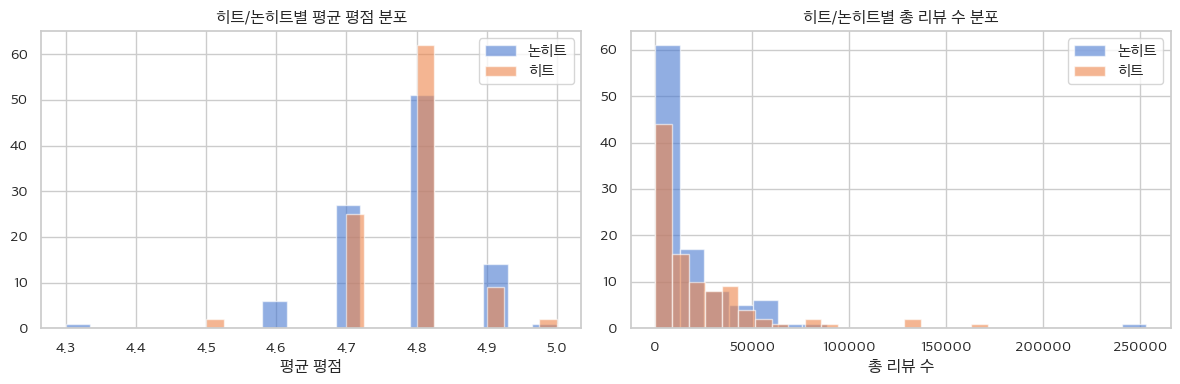

In [30]:
# 히트 vs 논히트: 평점·리뷰수 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ["rating_avg", "review_count_total"], ["평균 평점", "총 리뷰 수"]):
    for hit, grp in label_df.groupby("is_hit"):
        ax.hist(grp[col].dropna(), bins=20, alpha=0.6,
                label="히트" if hit else "논히트", edgecolor="white")
    ax.set_title(f"히트/논히트별 {label} 분포")
    ax.set_xlabel(label)
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/hit_vs_nonhit_dist.png", dpi=150)
plt.show()

In [31]:
# 히트 vs 논히트: 통계 요약
summary = label_df.groupby("is_hit")[["rating_avg", "review_count_total", "price"]].agg(["mean", "median"])
summary.index = ["논히트", "히트"]
display(summary.round(2))

rating_avg        review_count_total             price         
          mean median               mean   median     mean   median
논히트       4.77    4.8           17831.55   8139.5  25678.0  22900.0
히트        4.78    4.8           21915.47  11447.5  24786.6  23800.0

---
## 6. EDA 요약 & 다음 단계

### 6.1 데이터 품질 게이트

| 항목 | 결과 | 판정 |
|---|---|---|
| PK 중복 (products, reviews, rankings) | 0건 | ✅ |
| 논리 중복 (snapshot_date × category × rank) | 0건 | ✅ |
| 숫자 범위 위반 (가격·평점·순위) | 전체 0건 | ✅ |
| `price_original` NULL | 17개 (8.5%) | ✅ 정상 — 할인 미적용 상품 |
| `author_skin_type` NULL | 34% | ✅ 정상 — 미기재 허용 (설계상) |

### 6.2 launch_date_est 처리 정책

- **결정**: 그대로 사용
- **근거**: 불일치 1건 (바이오힐보 콜라겐 세럼, 31일 차이). 리뷰 최대 200건 수집 제한으로 발생한 edge case — 실제 초기 리뷰가 DB에 없어 first_review가 늦게 찍힘. 전체의 0.5%로 영향 미미. 피처 엔지니어링 시 해당 상품의 초기 14일 리뷰는 0건으로 처리됨.

### 6.3 라벨 정의 (확정)

- **기준**: `is_hit = (rank <= 30)`, 31~70위 제외
- **비율**: 히트 60개 / 논히트 60개 = **50:50** (스킨케어·색조 각 30:30)
- **결정 근거**: 50위 vs 51위는 당일 트래픽 차이 수준의 경계 노이즈. 1위~30위(명확한 히트)와 71위~100위(명확한 하위권)를 비교해 레이블 품질을 높임.

### 6.4 발견점

**1.** *(관찰)* 전체 리뷰 92%가 4~5점, 상품 평균 평점이 4.7~4.9 구간에 집중  
&nbsp;&nbsp;&nbsp;*(의미)* 평점 평균은 히트/논히트 변별력이 낮음 — 히트·논히트 중앙값 모두 4.8로 동일  
&nbsp;&nbsp;&nbsp;*(다음 단계 영향)* 평점 자체보다 초기 **별점 분산(`rating_2wk_std`)**, **시간에 따른 드리프트(`rating_drift`)** 피처가 더 유효할 것

**2.** *(관찰)* 200개 상품 중 164개(82%)가 2026년 출시 — 최신 상품 위주 수집  
&nbsp;&nbsp;&nbsp;*(의미)* 대부분 상품에서 출시 직후 14일 리뷰 데이터 확보 가능 → 리뷰 속도 분석에 충분한 표본  
&nbsp;&nbsp;&nbsp;*(다음 단계 영향)* `reviews_2wk_count`, `reviews_2wk_velocity_slope`가 핵심 피처가 될 것

**3.** *(관찰)* 히트/논히트 간 평점·리뷰수 단순 통계 차이 작음 (리뷰 수 중앙값 약 3,000건 차이)  
&nbsp;&nbsp;&nbsp;*(의미)* 현재 시점의 집계 지표만으로는 히트 예측이 어려움  
&nbsp;&nbsp;&nbsp;*(다음 단계 영향)* 초기 2주 내 **패턴(속도·기울기·분산)** 에서 변별력을 찾는 것이 이 프로젝트의 핵심 가설

### 6.5 피처 엔지니어링 아이디어 (→ 02_features.ipynb)

| 피처 | 설명 |
|---|---|
| `reviews_2wk_count` | 출시 후 14일 이내 리뷰 수 |
| `reviews_2wk_velocity_slope` | 리뷰 증가 기울기 (선형 회귀 기울기) |
| `rating_2wk_mean` | 초기 14일 평균 평점 |
| `rating_2wk_std` | 초기 별점 분산 |
| `rating_drift` | 초기 14일 평점 - 전체 평점 차이 |
| `photo_review_ratio_2wk` | 초기 포토 리뷰 비율 |
| `review_length_mean_2wk` | 초기 리뷰 평균 텍스트 길이 |
| `review_burst_3d` | 출시 후 3일 이내 리뷰 수 (초기 버스트 강도) |
| `skin_type_diversity` | 피부타입 다양성 (폭넓은 소비자층 여부) |